# Задание по курсу "Практическое введение в анализ изображений"

В данном файле приведена заготовка для решения практического задания по курсу "Практическое введение в анализ изображений".

Задание посвящено разработке метода автоматической сегментации минералов на микроскопических изображениях геологических аншлифов. Задание не имеет никаких ограничений по используемым подходам и методам. Тем не менее большинство вещей, расказанных в курсе "Практическое введение в анализ изображений", так или иначе связаны с тематикой задания и могут быть полезны.

Для вашего удобства рекомендуется использовать пакет [`petroscope`](https://github.com/xubiker/petroscope), содержащий набор методов, упрощающих работу с геологическими изображениями. Шаблон решения, приведенный ниже, опирается на этот пакет.

В качестве данных для обучения и тестирование в данном задании используется набор изображений [LumenStone](https://imaging.cs.msu.ru/en/research/geology/lumenstone) (подмножество S1v2).

Для начала установим пакет `petroscope`. Сделать это можно двумя способами:
1. Скачать актуальную версию дистрибутива с [GitHub](https://github.com/xubiker/petroscope/releases)
 и выполнить `pip install petroscope-0.0.12-py3-none-any.whl` (поменять номер версии на актуальный)
2. Или же просто выполнить `pip install petroscope`, установив актуальную версию с [PyPI](https://pypi.org/project/petroscope/).

В данном случае воспользуемся более простым способом:

In [ ]:
%pip install petroscope

Наш стандартный код для отображения изображений в jupiter notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def show(image, title: str = None, cmap: str = None):
    plt.imshow(image, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

Далее заведем переменную, указывающую путь до датасета LumenStone S1v2. Можно залить данные на google drive и примонтировать его к блокноту. Можно запускать все локально.
Для ускорения разработки также можно использовать версию LumenStone S1v2_x05, в которой разрешение изображений и масок уменьшено в 2 раза.

In [2]:
from pathlib import Path


# 1. Если хотите загрузить данные на google drive и работать в google colab, то:

# from google.colab import drive
# drive.mount('/content/drive')
# в этом примере я сделал в корне своего google drive папку dev,
# в ней intro_course_prak, куда положил LumenStone. Путь будет таким:
# ds_path = Path('/content/drive/MyDrive/dev/intro_course_prak/LumenStone/S1_v2_x05/')

# 2. Если хотите работать локально, то укажите путь до датасета:

ds_path = Path('S1_v2/')


In [3]:
from importlib.metadata import version
import petroscope, numpy
print("numpy:", numpy.__version__)
print("petroscope:", version("petroscope"))

numpy: 2.4.3
petroscope: 0.0.12


В данном задании мы будем работать с набором изображений LumenStone S1v2 (обновленная версия LumenStone S1v1.5). Описание разметки доступно в пакете `petroscope`. Выведем информацию о классах (номер класса, аббревиатура, название, цвет маски):

In [6]:
from petroscope.segmentation.classes import ClassSet, LumenStoneClasses

classset = LumenStoneClasses.S1()
for cl in classset.classes:
    print(cl)

[0, bg (background), color: #000000]
[1, ccp (chalcopyrite), color: #ffa500]
[2, gl (galena), color: #9acd32]
[4, br (bornite), color: #00bfff]
[6, py (pyrite), color: #2f4f4f]
[8, sh (sphalerite), color: #ee82ee]
[11, tnt (tenantite), color: #483d8b]


В `petroscope` есть много всего полезного для работы с геологическими изображениями аншлифов. Рассмотрим, напрмиер, открытие изображений и масок.

(2547, 3396, 3) float32


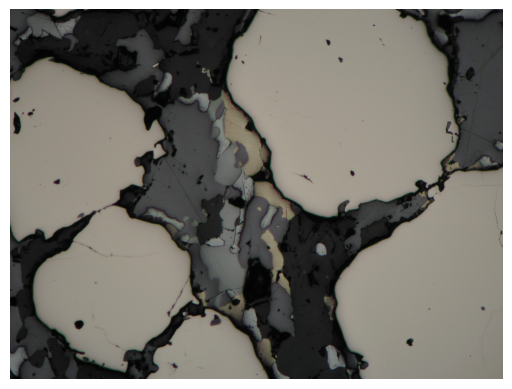

(2547, 3396) uint8
[ 0  1  2  6  8 11]


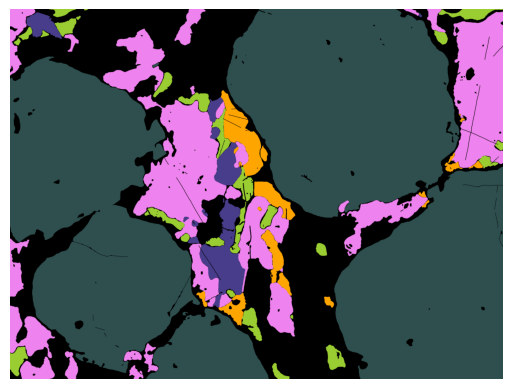

(2547, 3396, 50) float64
8
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [7]:
from petroscope.segmentation.utils import load_image, load_mask
from petroscope.segmentation.vis import SegmVisualizer


img = load_image(ds_path / "imgs/train/train_01.jpg", normalize=True)
print(img.shape, img.dtype)
show(img)

mask = load_mask(ds_path / "masks/train/train_01.png")
print(mask.shape, mask.dtype)

print(np.unique(mask))

mask_colored = SegmVisualizer.colorize_mask(
    mask,
    classset.colors_map(),
)[:,:,::-1]

show(mask_colored)

# demonstration of one-hot mask
mask_oh = load_mask(ds_path / "masks/train/train_01.png", one_hot=True, max_classes=LumenStoneClasses.max_classes())
print(mask_oh.shape, mask_oh.dtype)
print(mask[0,0])
print(mask_oh[0,0,:])


Ниже приведен код простейшей (насколько это возможно) модели для сегментации минералов, которая основывается на поиске минерала с ближайшим средним значением цвета из обучающей выборки для каждого пикселя тестового изображения. Ожидаемо, такой подход работает очень плохо. И вам предстоит его улучшить :)


Для реализации нашей модели сегментации отнаследуемся от абстрактного класса GeoSegmModel и реализуем все (ну почти) методы этого абстрактного класса. Это позволит нам использовать пакет ```petroscope``` для вычисления метрик, визуализации предсказаний и карты ошибок на тестовых данных.

In [8]:
import petroscope.segmentation as segm
from dataclasses import dataclass
from typing import Iterable
import numpy as np
from tqdm import tqdm

class ColorClusterMockModel(segm.GeoSegmModel):

    @dataclass
    class ColorCluster:
        n_pixels: int
        color_mean: np.ndarray

    def __init__(self, classes: ClassSet) -> None:
        super().__init__()
        self.classes = classes
        self.n_classes = len(classes)
        self.clusters = dict()


    def load(self, saved_path: Path, **kwargs) -> None:
        raise NotImplementedError

    def train(
        self, img_mask_paths: Iterable[tuple[Path, Path]], **kwargs
    ) -> None:
        for img_p, mask_p in tqdm(img_mask_paths):
            img = load_image(img_p, normalize=False)
            mask = load_mask(mask_p)
            for code in np.unique(mask):
                pixels = img[mask == code, :]
                cluster = ColorClusterMockModel.ColorCluster(
                    n_pixels=len(pixels),
                    color_mean=pixels.mean(axis=0),
                )
                if code not in self.clusters:
                    self.clusters[code] = []
                self.clusters[code].append(cluster)

        self.code_to_color = dict()
        for code, clusters in self.clusters.items():
            stack = np.stack([c.color_mean for c in clusters], axis=0)
            color = np.median(stack, axis=0)
            self.code_to_color[code] = color  

    def predict_image(self, image: np.ndarray) -> np.ndarray:
        # Sorted list of actual class codes, e.g. [0,1,2,4,6,8,11]
        codes = sorted(self.code_to_color.keys())
        # Squared distances for each class code
        dists = np.stack(
            [
                np.sum((image - self.code_to_color[code]) ** 2, axis=2)
                for code in codes
            ],
            axis=-1,
        )
        # Best code per pixel
        best_idx = np.argmin(dists, axis=-1)              # (H, W) indices in codes list
        code_array = np.array(codes, dtype=np.uint8)
        best_codes = code_array[best_idx]                 # (H, W) with real codes
        # Convert to one-hot over all possible classes (0..49)
        H, W = best_codes.shape
        n_classes = LumenStoneClasses.max_classes()       # 50
        pred = np.zeros((H, W, n_classes), dtype=np.float32)
        ys, xs = np.indices((H, W))
        pred[ys, xs, best_codes] = 1.0
        return pred

Подготовим датасет LumenStone S1v1.5 для работы с описанной моделью. Для этого нужно всего лишь создать список пар (путь до изображения, путь до маски) для обучающей и тестовой выборок.

In [9]:
# fill correct path to the dataset

train_img_mask_p = [
    (img_p, ds_path / "masks" / "train" / f"{img_p.stem}.png")
    for img_p in sorted((ds_path / "imgs" / "train").iterdir())
]
test_img_mask_p = [
    (img_p, ds_path / "masks" / "test" / f"{img_p.stem}.png")
    for img_p in sorted((ds_path / "imgs" / "test").iterdir())
]

print(train_img_mask_p)
print(test_img_mask_p)

[(WindowsPath('S1_v2/imgs/train/train_01.jpg'), WindowsPath('S1_v2/masks/train/train_01.png')), (WindowsPath('S1_v2/imgs/train/train_02.jpg'), WindowsPath('S1_v2/masks/train/train_02.png')), (WindowsPath('S1_v2/imgs/train/train_03.jpg'), WindowsPath('S1_v2/masks/train/train_03.png')), (WindowsPath('S1_v2/imgs/train/train_04.jpg'), WindowsPath('S1_v2/masks/train/train_04.png')), (WindowsPath('S1_v2/imgs/train/train_05.jpg'), WindowsPath('S1_v2/masks/train/train_05.png')), (WindowsPath('S1_v2/imgs/train/train_06.jpg'), WindowsPath('S1_v2/masks/train/train_06.png')), (WindowsPath('S1_v2/imgs/train/train_07.jpg'), WindowsPath('S1_v2/masks/train/train_07.png')), (WindowsPath('S1_v2/imgs/train/train_08.jpg'), WindowsPath('S1_v2/masks/train/train_08.png')), (WindowsPath('S1_v2/imgs/train/train_09.jpg'), WindowsPath('S1_v2/masks/train/train_09.png')), (WindowsPath('S1_v2/imgs/train/train_10.jpg'), WindowsPath('S1_v2/masks/train/train_10.png')), (WindowsPath('S1_v2/imgs/train/train_11.jpg'), Wi

Запуск "обучения" модели. В демонстрационных целях используются только 5 первых изображений из обучающего набора.

In [10]:
model = ColorClusterMockModel(classes=classset)
model.train(img_mask_paths=train_img_mask_p[:15]) # remove limit in future!
print("Trained classes:\n", "\n".join([f"{code}: {color}" for code, color in model.code_to_color.items()]))

100%|██████████| 15/15 [00:08<00:00,  1.80it/s]

Trained classes:
 0: [31.16534659 30.00550802 27.42827765]
1: [137.76533056 120.79096203  88.92301442]
2: [123.77885263 118.70836913 114.00230243]
6: [165.5719862  150.17027325 130.95916537]
8: [79.8906535  78.00990394 71.80528784]
11: [69.23076923 69.96153846 60.69230769]
4: [89.58630245 74.07072745 60.84061734]


Запуск тестирования модели. В демонстрационных целях используются только 3 первых изображений из тестового набора.

In [11]:
from petroscope.segmentation.eval import SegmDetailedTester

tester = SegmDetailedTester(
    out_dir=Path("output"),
    classes=classset,
    max_classes=LumenStoneClasses.max_classes(),
    void_pad=0,
    void_border_width=4,
    vis_segmentation=True,
)
res, res_void = tester.test_on_set(
    test_img_mask_p[:3], # remove limit in future!
    predict_func=model.predict_image,
    epoch=0,
)
print("results without void borders:\n", res)
print("results with void borders:\n", res_void)

testing:  33%|███▎      | 1/3 [01:14<02:28, 74.08s/it]


KeyboardInterrupt: 

В директории ```./output``` по результатам тестирования можете найти визуализацию сегментаций и текстовые файлы со значениями метрик.

## Что нужно теперь сделать?

Вам необходимо реализовать собственный метод автоматической сегментиации минералов. Разработанное решение должно быть оформлено в виде класса, отнаследованного от ```GeoSegmModel``` из пакета ```petroscope``` (как в примере выше).

Обратите внимание, что реализованный класс должен поддерживать автоматическое сохранение и загрузку модели (метод ```load```). Это позволит протестировать решение, не обучая модель заново.

Ваша цель - добиться как можно более высоких показаний метрик сегментации на тестовой выборке (тестовую выборку нельзя использовать при обучении или валидации!), ключевой является метрика mean_iou в режиме void_borders.

Решенные задания присылайте в виде ссылок на github репозиторий, или непосредственно ipynb ноутбуки. Обязательно проверьте воспроизводимость кода, чтобы я мог запустить вашу обученную модель!

<font color="red">
Рекомендуется после получения пайплайна с полными результатами обучения экспортировать ноутбук в pdf (файл -> печать) и положить этот pdf в репозиторий вместе с самим ноутбуком.
</font>

Удачи!